<a href="https://colab.research.google.com/github/gsathwik999/House-Price-Prediction-Using-ML-Analyzing-Data-Quality-and-Random-Forest-Performance/blob/main/House_Price_Prediction_Using_ML_Analyzing_Data_Quality_and_Random_Forest_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the Data

In [3]:
df = pd.read_csv( "train.csv")

# Reading the Data

In [4]:
df.head(10)  #first 10 rows

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


# Columns' Description

<i>SalePrice - the property's sale price in dollars. This is the target variable that you're trying to predict.
<br>
MSSubClass: The building class
<br>
MSZoning: The general zoning classification
<br>
LotFrontage: Linear feet of street connected to property
<br>
LotArea: Lot size in square feet
<br>
Street: Type of road access
<br>
Alley: Type of alley access
<br>
LotShape: General shape of property
<br>
LandContour: Flatness of the property
<br>
Utilities: Type of utilities available
<br>
LotConfig: Lot configuration
<br>
LandSlope: Slope of property
<br>
Neighborhood: Physical locations within Ames city limits
<br>
Condition1: Proximity to main road or railroad
<br>
Condition2: Proximity to main road or railroad (if a second is present)
<br>
BldgType: Type of dwelling
<br>
HouseStyle: Style of dwelling
<br>
OverallQual: Overall material and finish quality
<br>
OverallCond: Overall condition rating
<br>
YearBuilt: Original construction date
<br>
YearRemodAdd: Remodel date
<br>
RoofStyle: Type of roof
<br>
RoofMatl: Roof material
<br>
Exterior1st: Exterior covering on house
<br>
Exterior2nd: Exterior covering on house (if more than one material)
<br>
MasVnrType: Masonry veneer type
<br>
MasVnrArea: Masonry veneer area in square feet
<br>
ExterQual: Exterior material quality
<br>
ExterCond: Present condition of the material on the exterior
<br>
Foundation: Type of foundation
<br>
BsmtQual: Height of the basement
<br>
BsmtCond: General condition of the basement
<br>
BsmtExposure: Walkout or garden level basement walls
<br>
BsmtFinType1: Quality of basement finished area
<br>
BsmtFinSF1: Type 1 finished square feet
<br>
BsmtFinType2: Quality of second finished area (if present)
<br>
BsmtFinSF2: Type 2 finished square feet
<br>
BsmtUnfSF: Unfinished square feet of basement area
<br>
TotalBsmtSF: Total square feet of basement area
<br>
Heating: Type of heating
<br>
HeatingQC: Heating quality and condition
<br>
CentralAir: Central air conditioning
<br>
Electrical: Electrical system
<br>
1stFlrSF: First Floor square feet
<br>
2ndFlrSF: Second floor square feet
<br>
LowQualFinSF: Low quality finished square feet (all floors)
<br>
GrLivArea: Above grade (ground) living area square feet
<br>
BsmtFullBath: Basement full bathrooms
<br>
BsmtHalfBath: Basement half bathrooms
<br>
FullBath: Full bathrooms above grade
<br>
HalfBath: Half baths above grade
<br>
Bedroom: Number of bedrooms above basement level
<br>
Kitchen: Number of kitchens
<br>
KitchenQual: Kitchen quality
<br>
TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)
<br>
Functional: Home functionality rating
<br>
Fireplaces: Number of fireplaces
<br>
FireplaceQu: Fireplace quality
<br>
GarageType: Garage location
<br>
GarageYrBlt: Year garage was built
<br>
GarageFinish: Interior finish of the garage
<br>
GarageCars: Size of garage in car capacity
<br>
GarageArea: Size of garage in square feet
<br>
GarageQual: Garage quality
<br>
GarageCond: Garage condition
<br>
PavedDrive: Paved driveway
<br>
WoodDeckSF: Wood deck area in square feet
<br>
OpenPorchSF: Open porch area in square feet
<br>
EnclosedPorch: Enclosed porch area in square feet
<br>
3SsnPorch: Three season porch area in square feet
<br>
ScreenPorch: Screen porch area in square feet
<br>
PoolArea: Pool area in square feet
<br>
PoolQC: Pool quality
<br>
Fence: Fence quality
<br>
MiscFeature: Miscellaneous feature not covered in other categories
<br>
MiscVal: $Value of miscellaneous feature
<br>
MoSold: Month Sold
<br>
YrSold: Year Sold
<br>
SaleType: Type of sale
<br>
SaleCondition: Condition of sale

<h1>Cleaning and Exploration The Data

In [5]:

print("Data contains ",df.shape[0],"'row' and ",df.shape[1],"'column'")

Data contains  1460 'row' and  81 'column'


In [6]:
#check if Id contains Unique values
is_id_unique = df['Id'].nunique() ==df.shape[0]
is_id_unique

True

we notice that col "Id" has unique value so we will use it as index

In [7]:
df.set_index('Id', inplace=True)
df.head(2)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500


In [8]:
#Check for duplicated Vlaues
num_duplicated_rows = df.duplicated().sum()
print("Count of Duplicated rows is :",num_duplicated_rows)

Count of Duplicated rows is : 0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt    

<Axes: ylabel='Id'>

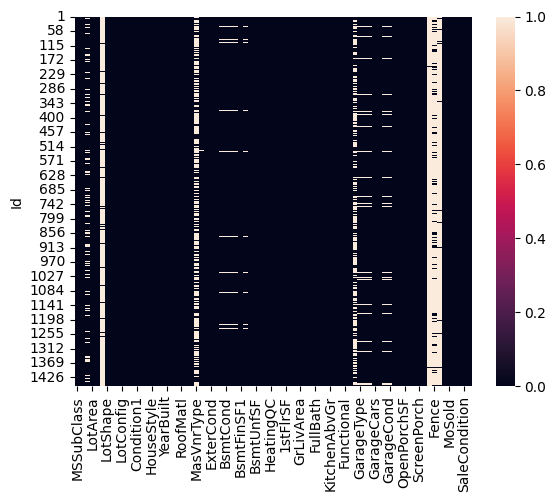

In [10]:
sns.heatmap(df.isnull()) #cols have Null value

In [11]:
#Getting only Cols that have NULL values and how many of them
flag=0
for col in df.columns:
    if(df[col].isnull().sum()>0):
        flag+=1
        print(f"Count of Null Values in {col.ljust(15)}: {df[col].isnull().sum()}")


print("_______________________________________________")
print ("There are ",flag,"col conatin Null values")
#1460 rows × 80 columns

Count of Null Values in LotFrontage    : 259
Count of Null Values in Alley          : 1369
Count of Null Values in MasVnrType     : 872
Count of Null Values in MasVnrArea     : 8
Count of Null Values in BsmtQual       : 37
Count of Null Values in BsmtCond       : 37
Count of Null Values in BsmtExposure   : 38
Count of Null Values in BsmtFinType1   : 37
Count of Null Values in BsmtFinType2   : 38
Count of Null Values in Electrical     : 1
Count of Null Values in FireplaceQu    : 690
Count of Null Values in GarageType     : 81
Count of Null Values in GarageYrBlt    : 81
Count of Null Values in GarageFinish   : 81
Count of Null Values in GarageQual     : 81
Count of Null Values in GarageCond     : 81
Count of Null Values in PoolQC         : 1453
Count of Null Values in Fence          : 1179
Count of Null Values in MiscFeature    : 1406
_______________________________________________
There are  19 col conatin Null values


In [12]:
#We can drop Alley, MasVnrType ,FireplaceQu ,PoolQC ,Fence ,MiscFeature
df.drop(columns=['Alley','MasVnrType','FireplaceQu','PoolQC','Fence','MiscFeature'],inplace=True)

In [13]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [14]:
#Getting Cols that have NULL values and float Data Type
for col in df.columns:
    if(df[col].dtype=='float'and df[col].isnull().sum()>0):
        print(f"Type of {col.ljust(15)}: {df[col].dtype}")


Type of LotFrontage    : float64
Type of MasVnrArea     : float64
Type of GarageYrBlt    : float64


In [16]:
#df['LotFrontage'] #Linear feet of street connected to property #has a float data type
df['LotFrontage'].fillna(df['LotFrontage'].mean(),inplace=True)
df['MasVnrArea'].fillna(df['MasVnrArea'].mean(),inplace=True)
df['GarageYrBlt'].fillna(df['GarageYrBlt'].mean(),inplace=True)

print("count of NULL Values in 'LotFrontage' : ",df['LotFrontage'].isnull().sum() )
print("count of NULL Values in 'MasVnrArea'  : ",df['MasVnrArea'].isnull().sum() )
print("count of NULL Values in 'GarageYrBlt' : ",df['GarageYrBlt'].isnull().sum() )

count of NULL Values in 'LotFrontage' :  0
count of NULL Values in 'MasVnrArea'  :  0
count of NULL Values in 'GarageYrBlt' :  0


<ipython-input-16-bf4982336297>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LotFrontage'].fillna(df['LotFrontage'].mean(),inplace=True)
<ipython-input-16-bf4982336297>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

In [17]:
for col in df.columns:
    if(df[col].dtype=='object'and df[col].isnull().sum()>0):
        print(f"Type of {col.ljust(15)}: {df[col].dtype}")

Type of BsmtQual       : object
Type of BsmtCond       : object
Type of BsmtExposure   : object
Type of BsmtFinType1   : object
Type of BsmtFinType2   : object
Type of Electrical     : object
Type of GarageType     : object
Type of GarageFinish   : object
Type of GarageQual     : object
Type of GarageCond     : object


In [18]:
df.fillna('UnKnown',inplace=True)
df.isnull().sum().sum()
#Now Data doesn't contain any Null values.

np.int64(0)

In [19]:
df.head(3)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500


In [20]:
df_temp=df[['YearBuilt','LotArea','OverallQual','OverallCond','GrLivArea','1stFlrSF','2ndFlrSF','BedroomAbvGr','OpenPorchSF','PoolArea','SalePrice']].describe()
df_temp

,YearBuilt,LotArea,OverallQual,OverallCond,GrLivArea,1stFlrSF,2ndFlrSF,BedroomAbvGr,OpenPorchSF,PoolArea,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,1971.267808,10516.828082,6.099315,5.575342,1515.463699,1162.626712,346.992466,2.866438,46.660274,2.758904,180921.195890
std,30.202904,9981.264932,1.382997,1.112799,525.480383,386.587738,436.528436,0.815778,66.256028,40.177307,79442.502883
min,1872.000000,1300.000000,1.000000,1.000000,334.000000,334.000000,0.000000,0.000000,0.000000,0.000000,34900.000000
25%,1954.000000,7553.500000,5.000000,5.000000,1129.500000,882.000000,0.000000,2.000000,0.000000,0.000000,129975.000000
50%,1973.000000,9478.500000,6.000000,5.000000,1464.000000,1087.000000,0.000000,3.000000,25.000000,0.000000,163000.000000
75%,2000.000000,11601.500000,7.000000,6.000000,1776.750000,1391.250000,728.000000,3.000000,68.000000,0.000000,214000.000000
max,2010.000000,215245.000000,10.000000,9.000000,5642.000000,4692.000000,2065.000000,8.000000,547.000000,738.000000,755000.000000


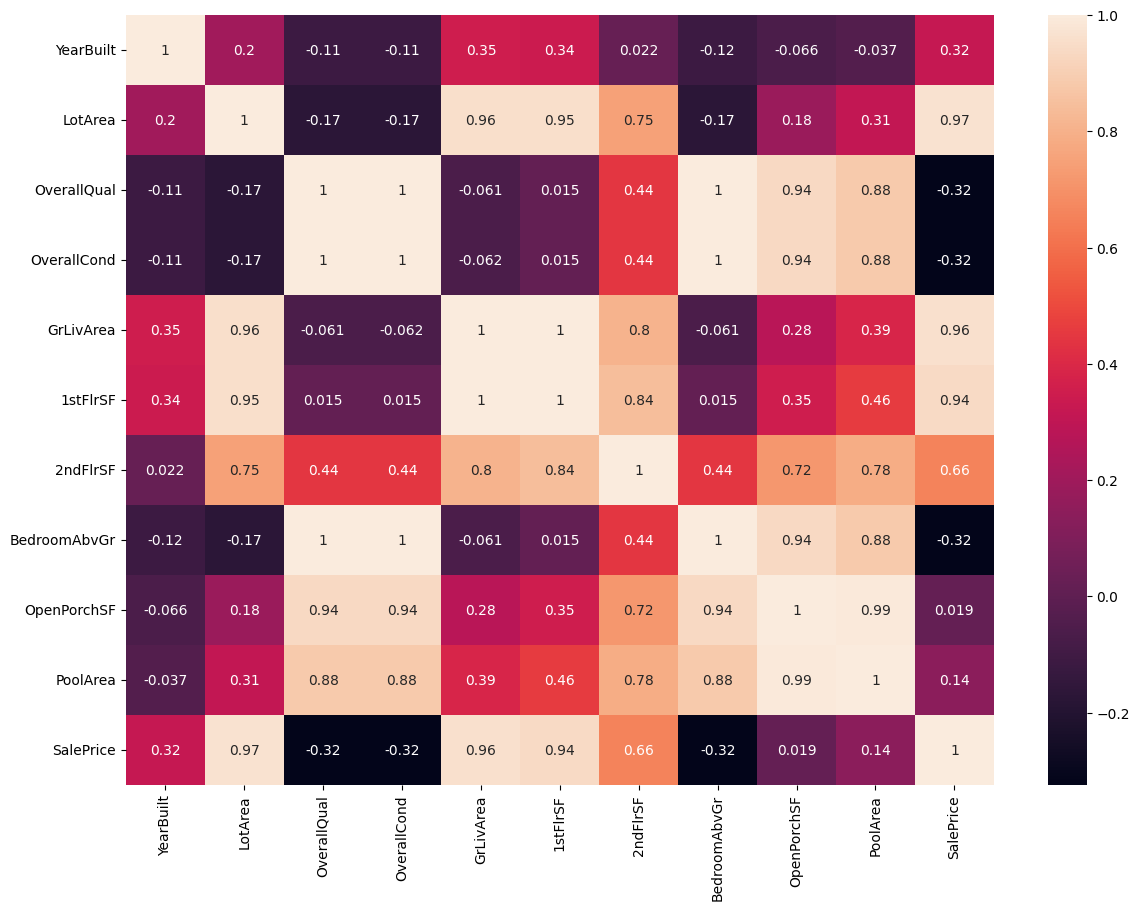

In [21]:
plt.figure(figsize=(14,10))
sns.heatmap(df_temp.corr(),annot=True)
plt.show()

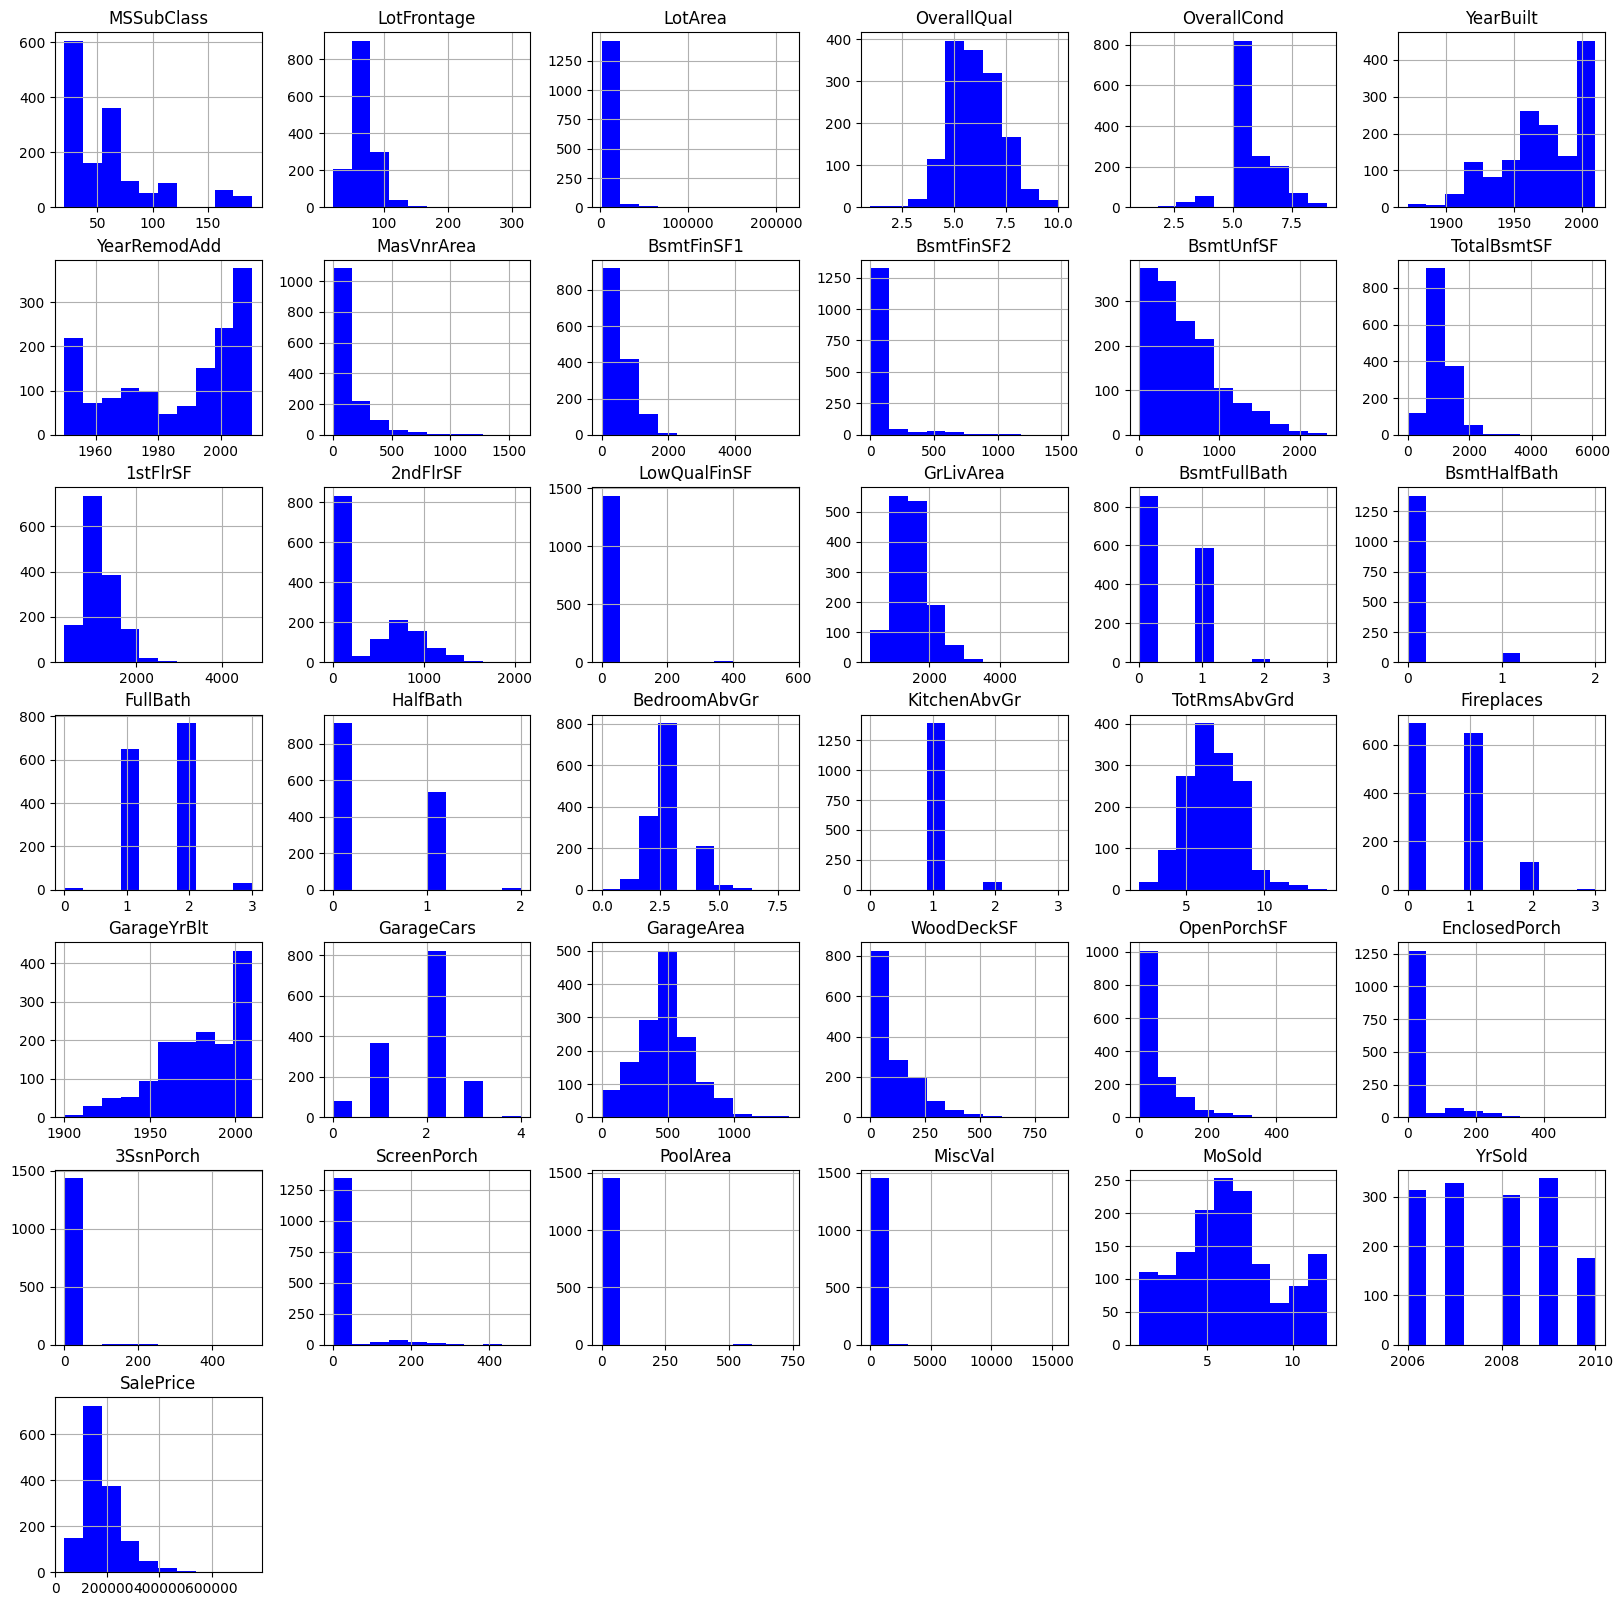

In [22]:
df.hist(figsize=(20,20),color='blue')  # Visualizations distribution columns that have a data type "Number "
plt.show()

<ipython-input-39-59c192264f4b>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(x='OverallQual', y='SalePrice', data=df, ci=None)


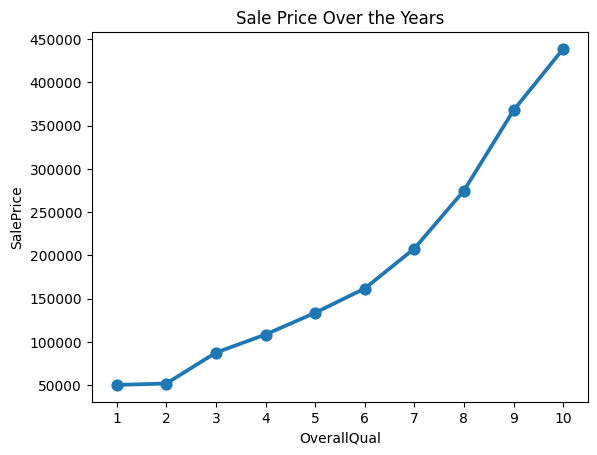

In [ ]:
#from heatmap we found a colleration between  overallQual and SalePrice
sns.pointplot(x='OverallQual', y='SalePrice', data=df, ci=None)
plt.title('Sale Price Over the Years')
plt.show()

From Heatmap we can relaize that relation between SalePrice and GrLivArea is large

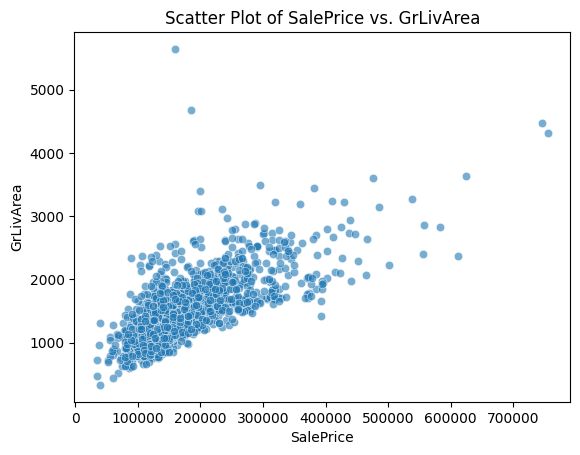

In [23]:
sns.scatterplot(x='SalePrice', y='GrLivArea', data=df,alpha=0.6)

plt.xlabel('SalePrice')
plt.ylabel('GrLivArea')
plt.title('Scatter Plot of SalePrice vs. GrLivArea')

plt.show()

# Building The Model  

# Feature and Target Selection

In [24]:
y = df["SalePrice"]
X = df[['YearBuilt','LotArea','OverallQual','OverallCond','GrLivArea','1stFlrSF','2ndFlrSF','BedroomAbvGr','OpenPorchSF','PoolArea','SalePrice']]
X

,YearBuilt,LotArea,OverallQual,OverallCond,GrLivArea,1stFlrSF,2ndFlrSF,BedroomAbvGr,OpenPorchSF,PoolArea,SalePrice
Id,,,,,,,,,,,
1,2003,8450,7,5,1710,856,854,3,61,0,208500
2,1976,9600,6,8,1262,1262,0,3,0,0,181500
3,2001,11250,7,5,1786,920,866,3,42,0,223500
4,1915,9550,7,5,1717,961,756,3,35,0,140000
5,2000,14260,8,5,2198,1145,1053,4,84,0,250000
...,...,...,...,...,...,...,...,...,...,...,...
1456,1999,7917,6,5,1647,953,694,3,40,0,175000
1457,1978,13175,6,6,2073,2073,0,3,0,0,210000
1458,1941,9042,7,9,2340,1188,1152,4,60,0,266500


# Normalizing the Data

In [25]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1))

# Spliting the Data

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled,y_scaled,test_size=.2,random_state=1)

# RandomForestRegressor

In [27]:
from sklearn.ensemble import RandomForestRegressor
model_R = RandomForestRegressor(n_estimators=1000, random_state=42)

# Fitting the model

In [28]:
model_R.fit(X_train,y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(n_estimators=1000, random_state=42)

# Predicting X_test

In [29]:
y_pred=model_R.predict(X_test)
print(y_pred[:10])

[0.2734408  0.20070743 0.12095681 0.06925941 0.14886172 0.4029145
 0.3467078  0.16120921 0.22225699 0.33320898]


In [30]:
result_df = pd.DataFrame({'Actual': y_test.flatten() , 'Predicted': y_pred.flatten() })
result_df

,Actual,Predicted
0,0.273018,0.273441
1,0.200805,0.200707
2,0.120955,0.120957
3,0.068879,0.069259
4,0.148729,0.148862
...,...,...
287,0.094848,0.094441
288,0.298292,0.298725
289,0.041105,0.044424
290,0.066796,0.066345


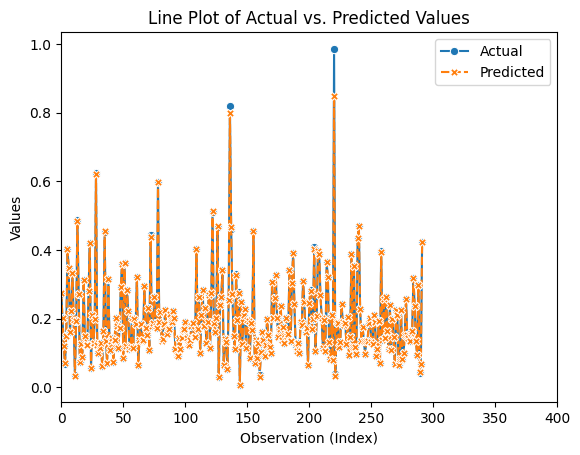

In [31]:
sns.lineplot(data=result_df, markers=True)
plt.xlabel('Observation (Index)')
plt.ylabel('Values')
plt.xlim(0,400)
plt.title('Line Plot of Actual vs. Predicted Values')
plt.show()

# Checking Accuracy of the Model

In [32]:
from sklearn.metrics import mean_squared_error ,mean_absolute_error,r2_score

In [33]:
acc = mean_absolute_error(y_pred,y_test)
print("Mean Absolute Error is: ",acc )

Mean Absolute Error is:  0.0008657388909074894


In [ ]:
score=r2_score(y_pred,y_test)
print("R-squared (coefficient of determination) score is : {:.2f}%".format(score * 100))

R-squared (coefficient of determination) score is : 99.49%


In [ ]:
score=model_R.score(X_train,y_train)
print("Accuracy for Training: {:.2f}%".format(score * 100))

Accuracy for Training: 99.91%


In [ ]:
score=model_R.score(X_test,y_test)
print("Accuracy for Testing: {:.2f}%".format(score * 100))

Accuracy for Testing: 99.52%
